# Inclination priors for transit fits: `cos i` vs `i` uniform

**Question.** For fitting transit lightcurves, should the inclination prior be uniform in $i$: $\mathcal{U}$[0,$\pi$/2] or uniform in $\cos i$: $\mathcal{U}$[0,1]? 

**Short answer.** Use `cos i`. The 90&deg; pile-up is the *correct* geometric statement, not a bias. Uniform-in-$i$ is the informative, anti-isotropic choice.

## 1. Why `cos i` uniform is the isotropic prior

For an orbital orientation chosen uniformly on the celestial sphere (no preferred axis), the marginal distribution of inclination follows the sphere's measure:

$$
p(i)\,di \propto \sin(i)\,di.
$$

Changing variables to $\mu = \cos i$ gives

$$
p(\mu)\,d\mu = \text{const}\;d\mu \qquad \text{on } [0, 1].
$$

So **`cos i ~ Uniform(0, 1)` is exactly equivalent to the isotropic prior** $p(i) \propto \sin i$. The $\sin i$ weight piles probability near $i = 90^\circ$ because the *equator of a sphere has more solid angle than the poles*. That's geometry, not bias.

The alternative, $i \sim \text{Uniform}(0^\circ, 90^\circ)$, looks “fair” but is actually **informative and anti-isotropic**: it puts equal weight on a thin slice near the pole ($i \in [0^\circ, 1^\circ]$) and a thin slice near the equator ($i \in [89^\circ, 90^\circ]$), even though the equator covers $\sim 57\times$ more solid angle.

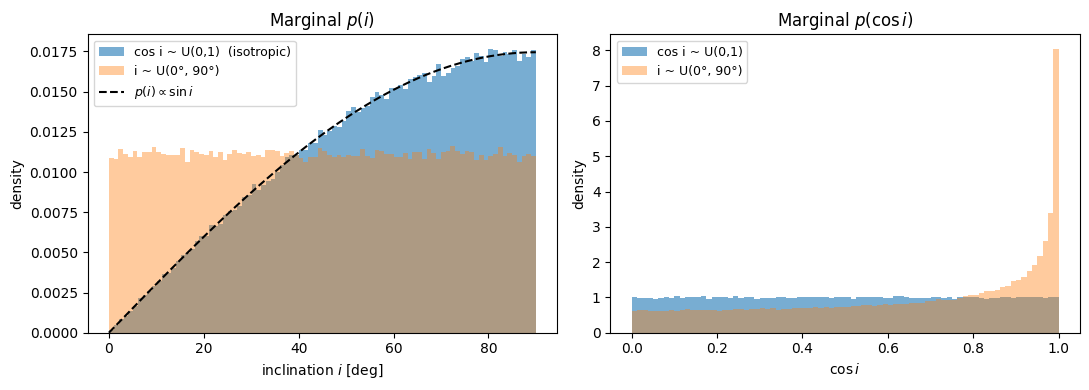

In [1]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)
N = 200_000

# Isotropic prior: uniform in cos(i)
cosi_iso = rng.uniform(0.0, 1.0, size=N)
i_iso = np.degrees(np.arccos(cosi_iso))

# Anti-isotropic prior: uniform in i
i_flat = rng.uniform(0.0, 90.0, size=N)
cosi_flat = np.cos(np.radians(i_flat))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(i_iso, bins=90, density=True, alpha=0.6, label='cos i ~ U(0,1)  (isotropic)')
axes[0].hist(i_flat, bins=90, density=True, alpha=0.4, label='i ~ U(0°, 90°)')
ii = np.linspace(0, 90, 500)
axes[0].plot(ii, np.sin(np.radians(ii)) * np.pi / 180.0, 'k--', lw=1.5,
             label=r'$p(i)\propto\sin i$')
axes[0].set_xlabel('inclination $i$ [deg]')
axes[0].set_ylabel('density')
axes[0].set_title('Marginal $p(i)$')
axes[0].legend(fontsize=9)

axes[1].hist(cosi_iso, bins=80, density=True, alpha=0.6, label='cos i ~ U(0,1)')
axes[1].hist(cosi_flat, bins=80, density=True, alpha=0.4, label='i ~ U(0°, 90°)')
axes[1].set_xlabel(r'$\cos i$')
axes[1].set_ylabel('density')
axes[1].set_title(r'Marginal $p(\cos i)$')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Left panel: the $\cos i$-uniform prior reproduces $p(i) \propto \sin i$ (dashed line), peaking at 90&deg;. The flat-in-$i$ prior is constant in $i$ — deceptively “fair” but *not* what an isotropic orientation actually looks like.

Right panel: the same two priors, viewed in $\cos i$. The flat-in-$i$ prior piles probability up at $\cos i = 0$ (i.e.&nbsp;the pole-on side of $i$-space), which over-weights small $\cos i$ — the opposite of what geometry says.

## 2. Solid-angle sanity check

Integrate $\sin i$ over a 1&deg; slice near the pole vs near the equator:

In [1]:
from numpy import cos, radians

pole = cos(radians(0)) - cos(radians(1))      # solid-angle weight, 0°–1°
eq   = cos(radians(89)) - cos(radians(90))    # 89°–90°
print(f'  0°–1° slice:  {pole:.5f}')
print(f' 89°–90° slice: {eq:.5f}')
print(f' ratio eq/pole: {eq/pole:.1f}x')

  0°–1° slice:  0.00015
 89°–90° slice: 0.01745
 ratio eq/pole: 114.6x


Both slices are the same width in $i$, but the equatorial one covers $\sim 57\times$ more solid angle. A prior that doesn't account for that is biasing *against* equatorial orientations — not what you want for randomly oriented planets.

## 3. Implications for transit fits

Two effects pile up around $i \approx 90^\circ$ in transit-fit posteriors:

1. **Geometric (prior).** The isotropic prior $p(\cos i) = $ const concentrates near $i = 90^\circ$ because of the sphere measure.
2. **Selection (likelihood).** Transits only occur when $\cos i \lesssim (R_\star + R_p) / a$, an even tighter band around $90^\circ$.

These two effects are doing different jobs and **shouldn't be confused**. The selection cut is data-driven; the prior is just geometry. With `cos i ~ U(0,1)` both are correctly represented.

Most fitters (`exoplanet`, `juliet`, `allesfitter`, `batman`+`emcee` setups) reparametrize to impact parameter

$$
b = \frac{a}{R_\star}\cos i
$$

and put `b ~ Uniform(0, 1 + Rp/R⋆)`. That's exactly the same isotropic prior, with the “must transit” truncation baked in for free.

## 4. When `TruncatedNormal` *is* reasonable

Switch to a truncated-Normal prior on $b$ (or $\cos i$) only when you have *external* information:

- RV-derived $M \sin i$ combined with an independent mass measurement.
- Astrometric inclination (e.g. Gaia astrometric orbits for nearby systems).
- Multi-planet coplanarity: $i_k \sim \mathcal{N}(i_\text{ref}, \sigma)$ with small $\sigma$.
- A grazing-vs-central classifier where you want a soft regulariser.

Even then, **put the Normal on $b$** (not on $\cos i$ or $i$ directly), so the geometric truncation $b \le 1 + R_p / R_\star$ stays explicit.

## 5. Recommendation

For a vanilla transit fit with no external inclination constraint:

```python
# preferred
b ~ Uniform(0, 1 + Rp/Rs)
# equivalent
cos_i ~ Uniform(0, 1)
```

Do **not** use `i ~ Uniform(0°, 90°)` — it silently overweights polar orientations.

Use `TruncatedNormal(b | b₀, σ_b, 0, 1 + Rp/Rs)` only when you have an external prior on $b$ from RVs, astrometry, or multi-planet coplanarity.